In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Create dataset
X, y, coef = make_regression(
    n_samples=200,
    n_features=20,
    n_informative=10,
    noise=10,
    coef=True,
    random_state=42
)

# Convert to DataFrame
feature_names = [f"Feature_{i}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y)

# Add multicollinearity (duplicate some features with noise)
X["Feature_dup1"] = X["Feature_0"] + np.random.normal(0, 0.1, size=X.shape[0])
X["Feature_dup2"] = X["Feature_1"] + np.random.normal(0, 0.1, size=X.shape[0])

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (200, 22)


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_dup1,Feature_dup2
0,0.198085,-0.144360,0.059218,-0.272724,-0.335785,-0.230935,0.013929,-1.503143,-0.245743,-0.054295,...,-1.106526,-0.259591,-2.696887,-0.024125,2.573360,1.848956,1.669022,-0.268889,0.122860,0.110290
1,-0.968046,-0.310308,-0.397558,1.171718,-0.399899,1.181891,1.237654,0.182501,-0.670115,0.487560,...,-1.422975,-0.044893,-1.176173,0.379768,-0.970124,-0.202524,0.269295,1.036088,-0.947523,-0.326897
2,-0.388177,0.170416,-0.337086,-1.975467,0.056650,-1.209695,-0.613403,0.486502,0.064474,-0.144088,...,1.490726,-0.070499,-0.939335,-0.302470,0.148667,1.530751,0.529693,-0.213443,-0.466304,0.211784
3,0.513908,0.179582,1.938929,1.187679,0.403730,0.283288,-1.000331,0.324359,-1.179040,0.201160,...,-1.345980,-0.903702,-0.464617,-0.677745,0.126380,0.586694,-0.024196,0.871297,0.371451,0.010624
4,-0.552223,0.632932,-0.570746,0.492451,-0.049464,-0.637740,-0.832356,0.382410,0.166452,2.455300,...,1.189017,-1.122722,0.289169,0.471416,1.420504,-0.623141,0.674819,-0.637387,-0.575687,0.705840


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
alphas = np.logspace(-3, 2, 50)

In [6]:
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

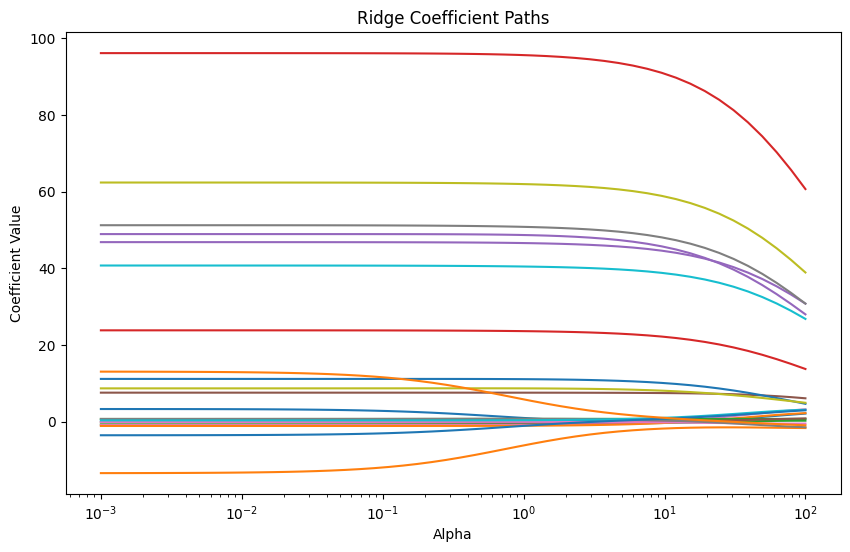

In [7]:
plt.figure(figsize=(10,6))
for i in range(ridge_coefs.shape[1]):
    plt.plot(alphas, ridge_coefs[:, i])

plt.xscale('log')
plt.title("Ridge Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.show()

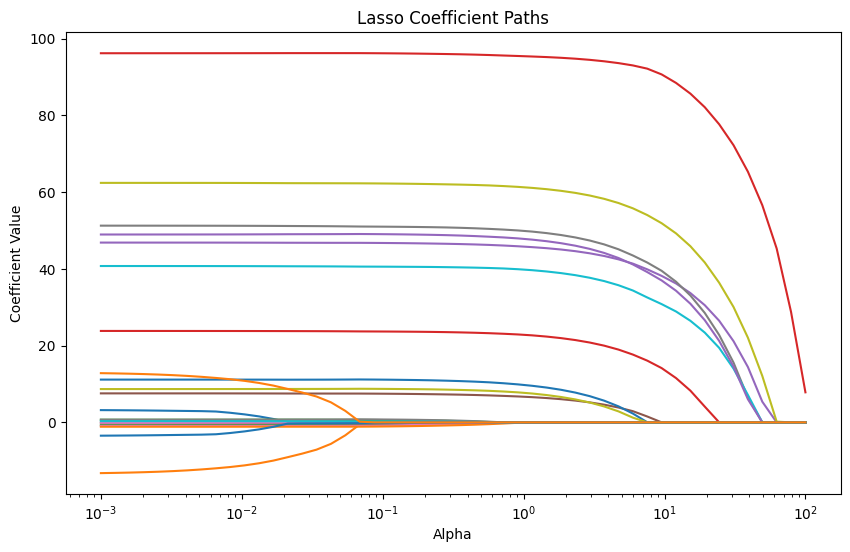

In [8]:
plt.figure(figsize=(10,6))
for i in range(lasso_coefs.shape[1]):
    plt.plot(alphas, lasso_coefs[:, i])

plt.xscale('log')
plt.title("Lasso Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.show()

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return mae, rmse, r2

In [10]:
results = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    mae, rmse, r2 = evaluate_model(ridge, X_train_scaled, X_test_scaled, y_train, y_test)
    results.append(["Ridge", alpha, mae, rmse, r2])

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    mae, rmse, r2 = evaluate_model(lasso, X_train_scaled, X_test_scaled, y_train, y_test)
    results.append(["Lasso", alpha, mae, rmse, r2])

# Linear Regression (no alpha)
lr = LinearRegression()
mae, rmse, r2 = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test)
results.append(["Linear", 0, mae, rmse, r2])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Alpha", "MAE", "RMSE", "R2"])

results_df.head()

,Model,Alpha,MAE,RMSE,R2
0,Ridge,0.001000,7.469784,10.444901,0.995365
1,Lasso,0.001000,7.460343,10.441206,0.995368
2,Ridge,0.001265,7.469585,10.444789,0.995365
3,Lasso,0.001265,7.457677,10.440151,0.995369
4,Ridge,0.001600,7.469332,10.444647,0.995365


In [11]:
lasso_cv = LassoCV(cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha = lasso_cv.alpha_
print("Best Alpha from LassoCV:", best_alpha)

Best Alpha from LassoCV: 0.40595467191716617


In [12]:
summary = results_df.groupby("Model").agg({
    "MAE": "min",
    "RMSE": "min",
    "R2": "max"
}).reset_index()

summary

,Model,MAE,RMSE,R2
0,Lasso,7.061916,10.182604,0.995595
1,Linear,7.470539,10.445325,0.995365
2,Ridge,7.222000,10.137170,0.995634


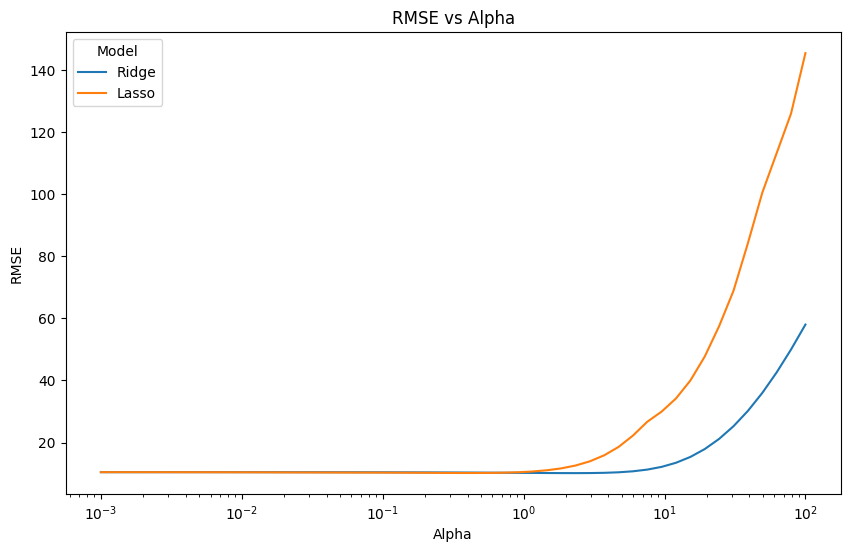

In [13]:
plt.figure(figsize=(10,6))
sns.lineplot(data=results_df[results_df["Model"] != "Linear"], x="Alpha", y="RMSE", hue="Model")
plt.xscale('log')
plt.title("RMSE vs Alpha")
plt.show()

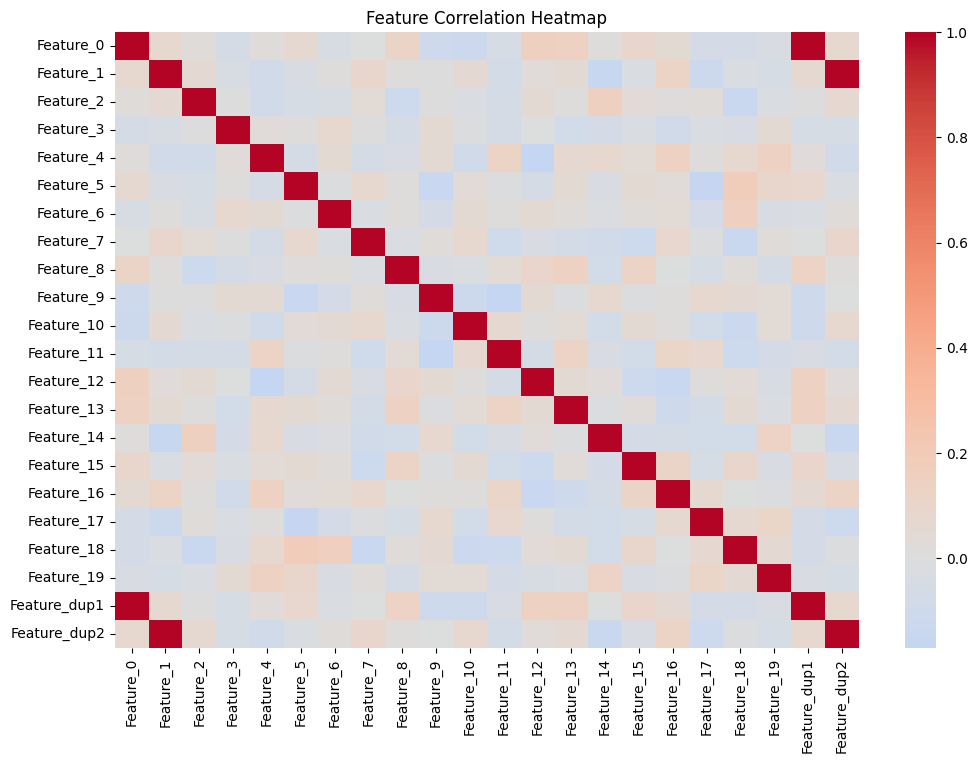

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

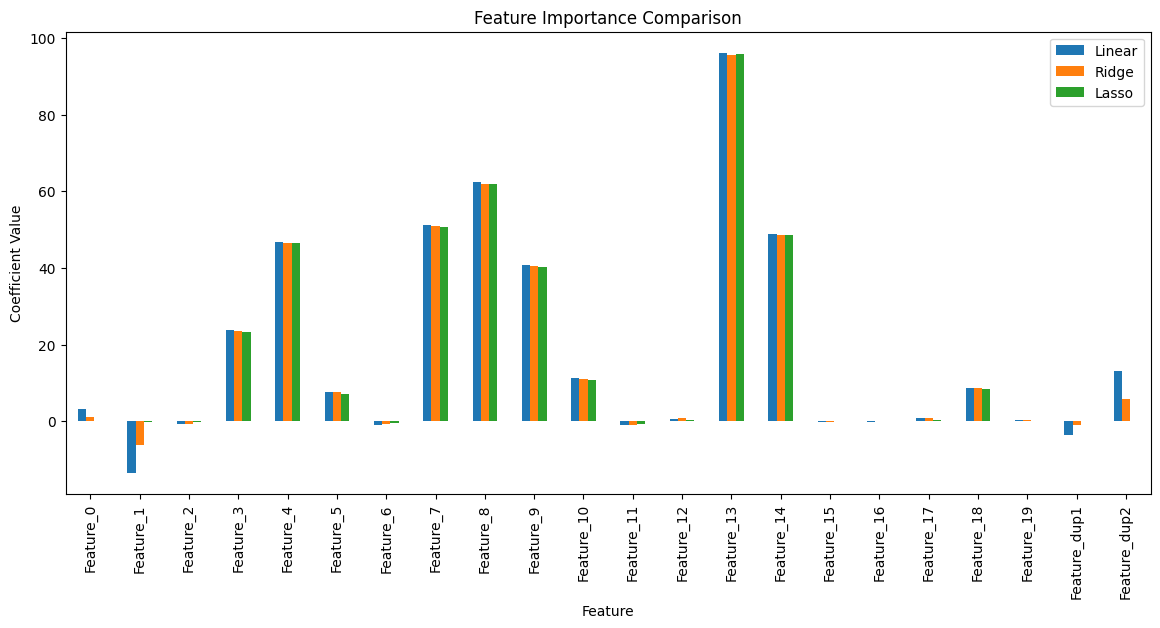

In [15]:
# Train final models
ridge_final = Ridge(alpha=1)
lasso_final = Lasso(alpha=best_alpha)
lr_final = LinearRegression()

ridge_final.fit(X_train_scaled, y_train)
lasso_final.fit(X_train_scaled, y_train)
lr_final.fit(X_train_scaled, y_train)

# Create DataFrame
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr_final.coef_,
    "Ridge": ridge_final.coef_,
    "Lasso": lasso_final.coef_
})

coef_df.set_index("Feature").plot(kind="bar", figsize=(14,6))
plt.title("Feature Importance Comparison")
plt.ylabel("Coefficient Value")
plt.show()

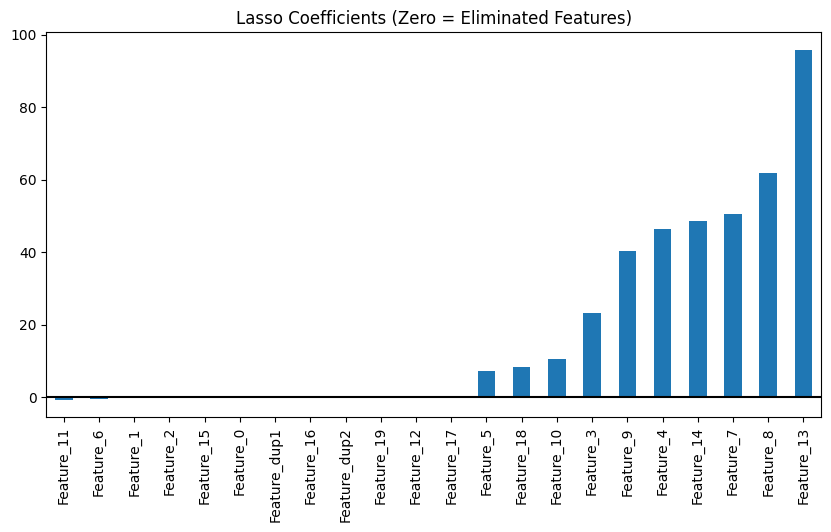

In [16]:
plt.figure(figsize=(10,5))

lasso_coeffs = pd.Series(lasso_final.coef_, index=X.columns)

lasso_coeffs.sort_values().plot(kind='bar')
plt.title("Lasso Coefficients (Zero = Eliminated Features)")
plt.axhline(0, color='black')
plt.show()

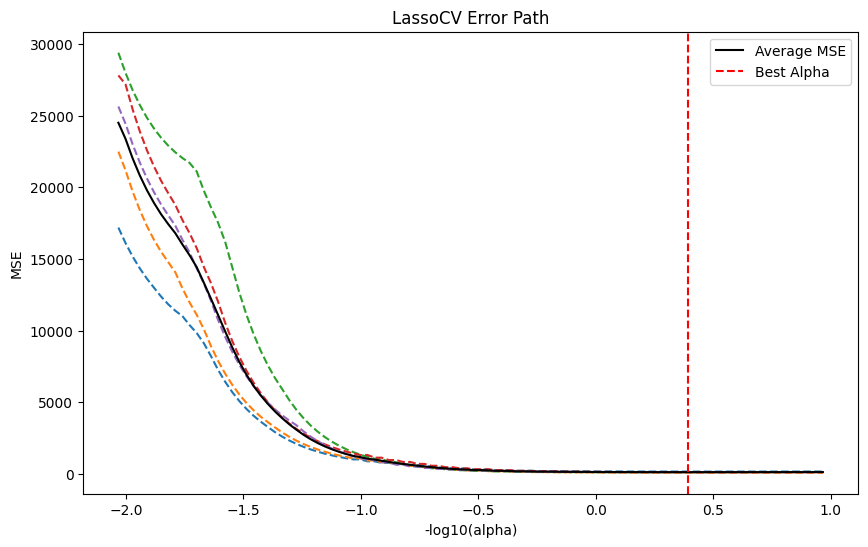

In [17]:
m_log_alphas = -np.log10(lasso_cv.alphas_)

plt.figure(figsize=(10,6))
for i in range(lasso_cv.mse_path_.shape[1]):
    plt.plot(m_log_alphas, lasso_cv.mse_path_[:, i], linestyle='--')

plt.plot(m_log_alphas, lasso_cv.mse_path_.mean(axis=1), color='black', label='Average MSE')

plt.axvline(-np.log10(best_alpha), linestyle='--', color='red', label='Best Alpha')

plt.xlabel('-log10(alpha)')
plt.ylabel('MSE')
plt.title('LassoCV Error Path')
plt.legend()
plt.show()

In [18]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X_real = pd.DataFrame(data.data, columns=data.feature_names)
y_real = pd.Series(data.target)

print(X_real.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [19]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)

preds = elastic.predict(X_test_scaled)

print("ElasticNet R2:", r2_score(y_test, preds))

ElasticNet R2: 0.9943845138671111
